In [59]:
import sys
import pandas as pd
import phik
import matplotlib
import seaborn as sns
from matplotlib.ticker import PercentFormatter

print(f"Путь к Python: {sys.executable}")
print(f"Версия Python: {sys.version}")
print(f"pandas: {pd.__version__}")
print(f"phik: {phik.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"Бэкенд pandas (plotting): {pd.options.plotting.backend}")

Путь к Python: D:\Learn\YandexPracticum\DataScience1\yp_data_science_tasks\sprint7_pandas\venv\Scripts\python.exe
Версия Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
pandas: 3.0.2
phik: 0.12.5
matplotlib: 3.10.8
seaborn: 0.13.2
Бэкенд pandas (plotting): matplotlib


# Исследование профиля нелояльных клиентов банка «Метанпром»

## Цель и задачи  

**Цель:** Провести исследовательский анализ данных клиентов банка «Метанпром» с выявлением портрета клиентов, которые склонны уходить из банка.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить взаимосвязь данных в столбце `Сhurn` с другими данными.
4. Сформулировать выводы по проведённому анализу.


## Данные

Для анализа поступили данные о клиентах банка «Метанпром». Данные состоят из двух датасетов:

- `bank_information.csv` — информация об использовании клиентом услуг банка;
- `clients_information.csv` —  персональная информация клиентов.

### Описание датасета `bank_information`

- `userid` — идентификатор клиента;
- `score` — баллы кредитного скоринга;
- `Objects` — количество объектов в собственности клиента;
- `Balance` — баланс на счёте клиента;
- `Products` — количество продуктов, которыми пользуется клиент;
- `CreditCard` — есть ли у клиента кредитная карта;
- `Loyalty` — считается ли клиент активным;
- `estimated_salary` — заработная плата клиента;
- `Churn` — ушёл ли клиент из банка.

### Описание датасета `clients_information`

- `userid` — идентификатор клиента;
- `LastName` — фамилия клиента;
- `FirstName` — имя клиента;
- `City` — город обращения в банк;
- `Gender` — пол;
- `Age` — возраст.


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `bank_information` и `clients_information`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik_matrix для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `bank_df` и `clients_df`.

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные bank_df и clients_df
bank_df = pd.read_csv('https://code.s3.yandex.net/datasets/bank_information.csv')
clients_df = pd.read_csv('https://code.s3.yandex.net/datasets/clients_information.csv')

Познакомимся с данными датасета `bank_information.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
# Выводим первые строки датафрейма на экран
bank_df.head()

,userid,score,Objects,Balance,Products,CreditCard,Loyalty,estimated_salary,Churn
0,15677338,619,2,NaN,1,1,1,101348.88,1
1,15690047,608,1,83807.86,1,0,1,112542.58,0
2,15662040,502,8,159660.80,3,1,0,113931.57,1
3,15744090,699,1,NaN,2,0,0,93826.63,0
4,15780624,850,2,125510.82,1,1,1,79084.10,0


In [5]:
# Выводим информацию о датафрейме
bank_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int64  
 2   Objects           10000 non-null  int64  
 3   Balance           6383 non-null   float64
 4   Products          10000 non-null  int64  
 5   CreditCard        10000 non-null  int64  
 6   Loyalty           10000 non-null  int64  
 7   estimated_salary  10000 non-null  float64
 8   Churn             10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.3 KB


Датасет `bank_information.csv` содержит 9 столбцов и 10000 строк, в которых представлена информация об использовании клиентами услуг банка.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов лучше привести к одному виду, например snake case.
- Все представленные данные содержат числовые значения и хранятся в типах данных `int64` или `float64`. Значения в столбцах `score`, `Objects`, `Products`, `CreditCard`, `Loyalty` и `Churn` представлены целыми числами. Часть их них показывает наличие у клиента того или иного признака и содержит значения 1 или 0 — размерность этих данных можно оптимизировать.
- Пропуски содержатся только в столбце `Balance`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `clients_information.csv`.

In [6]:
# Выводим первые строки датафрейма на экран
clients_df.head()

,userid,LastName,FirstName,Age,Gender,City
0,15677338,Лапина,Евпраксия,42,Ж,Ярославль
1,15690047,Александрова,Акулина,41,Ж,Рыбинск
2,15662040,Лаврентьева,Анна,42,Ж,Ярославль
3,15744090,Никитина,Олимпиада,39,Ж,Ярославль
4,15780624,Некрасова,Майя,43,Ж,Рыбинск


In [7]:
# Выводим информацию о датафрейме
clients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userid     10000 non-null  int64
 1   LastName   10000 non-null  str  
 2   FirstName  10000 non-null  str  
 3   Age        10000 non-null  int64
 4   Gender     10000 non-null  str  
 5   City       10000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 468.9 KB


Датасет `clients_information.csv` содержит 6 столбцов и 10000 строк, в которых представлена информация о клиентах банка. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов лучше привести к единому виду, например snake case.
- Типы данных соответствуют содержимому. Тип данных для столбца `Age` можно оптимизировать с понижением размерности. Маловероятно, что он хранит сильно завышенные значения.
- Пропусков на первый взгляд нет, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных.
- Значения в столбцах соответствуют описанию.

Первичное знакомство показывает, что данные хорошего качества — в них практически нет пропущенных значений, а сами данные соответствуют описанию и выглядят корректными. Настало время следующего этапа — предобработки данных.

---

## 2. Предобработка данных

### 2.1. Меняем названия, или метки, столбцов датафрейма

Для переименования используем метод `rename()`, которому передадим словарь с новыми названиями столбцов. Однако сначала выведем все названия на экран — так будет удобнее составлять словарь.

In [8]:
# Выводим названия столбцов датафрейма bank_df
bank_df.columns

Index(['userid', 'score', 'Objects', 'Balance', 'Products', 'CreditCard',
       'Loyalty', 'estimated_salary', 'Churn'],
      dtype='str')

In [9]:
# Передаём методу rename() словарь с названиями столбцов
bank_df = bank_df.rename(columns={'userid': 'userid',
                                  'Objects': 'objects',
                                  'Balance': 'balance',
                                  'Products': 'products',
                                  'CreditCard': 'credit_card',
                                  'Loyalty': 'loyalty',
                                  'Churn': 'churn'})

В названиях столбцов мы поменяли стиль и исправили так называемый CamelCase. При CamelCase (англ. «верблюжий регистр») каждое слово начинается с большой буквы, а между словами нет пробелов и других символов.

Чтобы из CamelCase перейти в snake_case, необходимо все заглавные символы сделать строчными, а между словами добавить подчёркивание `_`. Напишем такую функцию:

In [10]:
# Напишем функцию для корректировки названия столбцов из CamelCase в snake_case
def col_to_snake_case(df):
    """
    Функция приводит названия столбцов из CamelCase в snake_case.
    Пример: столбец FirstName станет first_name.
    В качестве аргументов принимает датафрейм.
    Перебирает столбцы и проверяет каждый столбец.
    Если первый символ является заглавной буквой, то он меняется на прописную.
    Если в названии отыскиваются другие заглавные буквы, перед ними вставляется символ
    подчёркивания, и буква меняется на прописную.
    Функция возвращает исправленный датафрейм.
    """

    for col in df.columns:
        str_bad = col
        if str_bad[0].isupper():
            str_bad = str_bad[0].lower() + str_bad[1:]
        for index_s, item_s in enumerate(str_bad):
            if item_s.isupper():
                str_bad = str_bad[:index_s] + '_' + str_bad[index_s].lower() + str_bad[index_s + 1:]
        df = df.rename(columns={col: str_bad})
    return df

В качестве аргумента функция принимает датафрейм. Она перебирает все значения `df.columns`, то есть названия столбцов. Условие  `if str_bad[0].isupper()` проверяет, является ли первая буква названия заглавной. Если да, то её регистр поменяется. Затем перебираются все символы названия столбца `for index_s, item_s in enumerate(str_bad)`. Если встречается ещё один заглавный символ, то его регистр также меняется на нижний, и перед символом добавляется знак `_`. Применим функцию к датафрейму `clients_df`:

In [11]:
# Применяем функцию col_to_snake_case()
clients_df = col_to_snake_case(clients_df)

In [12]:
# Выводим названия столбцов датафрейма clients_df
clients_df.columns

Index(['userid', 'last_name', 'first_name', 'age', 'gender', 'city'], dtype='str')

In [13]:
# Выводим названия столбцов датафрейма clients_df
clients_df.columns

Index(['userid', 'last_name', 'first_name', 'age', 'gender', 'city'], dtype='str')

Названия столбцов были скорректированы. Теперь можно перейти к преобразованию типов данных.

---

### 2.2. Оптимизируем типы данных

С данными банка здесь работы не так много — понадобится только провести оптимизацию целочисленных данных. В целом этот шаг можно было бы пропустить, особенно если данных немного — такое несоответствие не будет ошибкой при обработке данных. Однако для примера оставим этот шаг и проведём оптимизацию целочисленных типов данных.

Для оптимизации будем использовать метод `pd.to_numeric` с аргументом `downcast='integer'`:

In [14]:
# Оптимизируем целочисленный тип данных в датафрейме bank_df
for column in ['score','objects','products',
               'credit_card','loyalty','churn']:
    bank_df[column] = pd.to_numeric(bank_df[column],
                                    downcast='integer')

# Оптимизируем целочисленный тип данных в датафрейме clients_df
clients_df['age'] = pd.to_numeric(clients_df['age'], downcast='integer')

In [15]:
# Проверим типы данных в датафрейме bank_df с помощью атрибута dtypes
bank_df.dtypes

userid                int64
score                 int16
objects                int8
balance             float64
products               int8
credit_card            int8
loyalty                int8
estimated_salary    float64
churn                  int8
dtype: object

In [16]:
# Проверим типы данных в датафрейме clients_df с помощью атрибута dtypes
clients_df.dtypes

userid        int64
last_name       str
first_name      str
age            int8
gender          str
city            str
dtype: object

Типы данных были успешно оптимизированы с понижением размерности целочисленных данных.

---

### 2.3. Проверяем наличие пропусков в данных

При первичном анализе мы обнаружили пропуски в столбце `balance` датафрейма `bank_df`. Узнаем абсолютное и относительное количество пропусков в этом столбце.

In [17]:
# Применяем метод isna() к датафрейму bank_df
bank_df.isna().sum()

userid                 0
score                  0
objects                0
balance             3617
products               0
credit_card            0
loyalty                0
estimated_salary       0
churn                  0
dtype: int64

In [18]:
# Подсчитываем долю строк с пропусками
bank_df.isna().sum() / bank_df.shape[0]

userid              0.0000
score               0.0000
objects             0.0000
balance             0.3617
products            0.0000
credit_card         0.0000
loyalty             0.0000
estimated_salary    0.0000
churn               0.0000
dtype: float64

В датафрейме `bank_df` обнаружено 3617 пропусков в столбце `balance` — это 36% данных. Количество пропусков достаточно большое, чтобы их просто удалить.

Пропуски в этом столбце могут быть вызваны:
- Клиент не пользуется услугами банка, которые подразумевают открытие счёта. Среди таких услуг, к примеру, страхование. Однако у нас нет данных о типе услуги клиента, поэтому достоверно проверить эту гипотезу не получится. Этот тип пропусков можно отнести к типу MNAR.
- При обработке данных произошёл технический сбой. Технические ошибки могут привести к пропускам в данных, включая случаи, когда баланс не был записан. Этот тип пропусков можно отнести к типу MCAR.
- Клиент закрыл свой счёт и прекратил пользоваться услугами банка. Если клиент ушёл из банка и закрыл счёт, это также может быть причиной отсутствия данных о балансе. Можно проверить эту гипотезу, если проанализировать значения в столбцах `churn` и `products` в строках с пропусками. Этот тип пропусков можно отнести к типу MAR.


Чтобы разобраться с причиной пропусков, обычно анализируют возможные взаимосвязи пропусков с другими данными. Для этого добавим новый столбец-признак `is_balance`, который укажет на наличие пропуска в столбце `balance`.

Если в строке нет пропуска и в ней хранится информация о балансе, то значение в новом столбце будет 1, то есть `True`. Если в строке пропуск и баланса нет, то в столбец войдёт 0, то есть `False`. Такой подход помогает присвоить данным бинарный признак, как, например, в столбце `churn`. Затем можно использовать эти данные для изучения корреляции между данными с пропусками. Этот признак также можно использовать для группировки данных и сравнения результатов по данным с пропусками и без.

Напишем небольшую функцию:

In [19]:
# Определяем функцию, которая создаст новый столбец с бинарным признаком в зависимости от наличия данных в другом столбце
def create_is_na(x):
    """
    Функция создаёт новый столбец с бинарным признаком, который указывает
    на наличие данных в столбце. Функция применяется к столбцу после метода isna()
    """
    if x:
        return 0
    return 1

Функция применяется к столбцу, в котором следует проверить данные, после метода `isna()`. Как вы знаете, этот метод проверяет пропуски в данных и, если пропуск есть, возвращает `True`. В случае `True` срабатывает условие `if x` — функция возвращает 0, что означает, что в столбце нет данных. Если пропуска нет, метод `isna()` вернёт `False`. Тогда условие `if x` не сработает, и код вернёт 1. Применим эту функцию к столбцу `balance` и создадим новый столбец `is_balance`:

In [20]:
# Создаём столбец is_balance с помощью функции create_is_na
bank_df['is_balance'] = bank_df['balance'].isna().apply(create_is_na)

После того как столбец-признак `is_balance` был создан, можно посчитать средние значения или медиану по другим столбцам. Это поможет получить характеристики клиентов с пропуском и без пропуска в столбце `balance`. Для этого проведём агрегацию данных:

- Для данных с дискретными признаками `objects` и `products` будем использовать медиану `median`. Для таких значений среднее может быть дробным числом, а медиана, как правило, будет числом целым, которое проще интерпретировать.
- Для непрерывных вещественных данных `score` и `estimated_salary` используем среднее `mean`, чтобы охарактеризовать типичное значение.
- Для бинарных данных `credit_card`, `loyalty` и `churn` также используем среднее значение `mean` — оно будет соответствовать доли значений с признаком 1.

In [21]:
# Проводим агрегацию данных по полю is_balance
bank_df.groupby('is_balance').agg({
    'score':'mean',
    'objects':'median',
    'products':'median',
    'credit_card':'mean',
    'loyalty':'mean',
    'churn':'mean',
    'estimated_salary':'mean'
})

,score,objects,products,credit_card,loyalty,churn,estimated_salary
is_balance,,,,,,,
0,649.452861,5.0,2.0,0.716616,0.517832,0.138236,98983.559549
1,651.138493,5.0,1.0,0.699201,0.513552,0.240796,100717.352956


Можно сделать такие выводы о связи между пропусками в столбце `balance` и другими характеристиками клиентов:

- У клиентов с пропусками в `balance` в среднем больше продуктов, чем у клиентов без пропусков: у клиентов с пропусками в среднем два продукта, а у клиентов без пропусков — только один.
- Клиенты с указанным балансом чаще перестают пользоваться услугами банка, а количество объектов недвижимости не влияет на наличие пропуска в столбце `balance`.

Пропуски в столбце `balance`, скорее всего, неслучайны и могут зависеть от разных факторов, о которых у нас нет информации. Например, от названия продукта.

---

Далее проверим, встречаются ли в данных значения-индикаторы, которые можно рассматривать как пропуски. Иногда для анализа поступают уже частично или полностью подготовленные данные. Если вы не знаете, по какому алгоритму происходили первичный сбор и обработка данных, лучше дополнительно проверить, использовались ли значения-индикаторы для замены пропусков. Это поможет понять качество данных и избежать ошибок при их агрегации, когда значение-индикатор будет учитываться при расчёте среднего или медианы, что исказит исходные данные.

Посмотрим на уникальные значения в ключевых данных — среди них количество продуктов, объекты недвижимости, наличие кредитной карты, специальные условия обслуживания и признак, по которому клиент ушёл из банка.

In [22]:
# Проверяем уникальные значения в столбцах
for column in ['objects', 'products', 'credit_card', 'loyalty', 'churn']:
    print(f'Уникальные значения в столбце {column}:')
    print(bank_df[column].sort_values().unique())
    print()

Уникальные значения в столбце objects:
[ 0  1  2  3  4  5  6  7  8  9 10]

Уникальные значения в столбце products:
[1 2 3 4]

Уникальные значения в столбце credit_card:
[0 1]

Уникальные значения в столбце loyalty:
[0 1]

Уникальные значения в столбце churn:
[0 1]



Все значения выглядят корректными. Теперь можно перейти к изучению дубликатов в данных.

---

### 2.4. Явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [23]:
# Проверяем полные дубликаты в датафрейме bank_df
bank_df.duplicated().sum()

np.int64(0)

In [24]:
# Проверяем полные дубликаты в датафрейме clients_df
clients_df.duplicated().sum()

np.int64(0)

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id` клиентов должны быть уникальными, то есть каждая строка в данных — уникальный клиент:

In [25]:
# Проверяем неявные дубликаты в датафрейме bank_df
bank_df.duplicated(subset='userid').sum()

np.int64(0)

In [26]:
# Проверяем неявные дубликаты в датафрейме clients_df
clients_df.duplicated(subset='userid').sum()

np.int64(0)

Тут тоже всё хорошо — каждая строка соответствует уникальному клиенту. Теперь проверим корректность написания категориальных значений в данных `clients_df`.

In [27]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['gender', 'city']:
    print(f'Уникальные значения в столбце {column}:')
    print(clients_df[column].sort_values().unique())
    print()

Уникальные значения в столбце gender:
<StringArray>
['Ж', 'М']
Length: 2, dtype: str

Уникальные значения в столбце city:
<StringArray>
['Ростов Великий', 'Рыбинск', 'Ярославль']
Length: 3, dtype: str



В обозначении пола клиента и его города регистрации также нет ошибок.

---

### 2.5. Промежуточные выводы после предобработки

На этом предобработка завершена. Предоставленные данные хорошего качества и требуют не так много действий по предобработке. Однако, независимо от качества данных, лучше завершить этот этап небольшим промежуточным выводом: отметить основные действия и ошибки, с которыми вы столкнулись на этом шаге.

В результате предобработки данных были выполнены следующие действия:

- Скорректированы названия столбцов — их привели к стилю snake case;
- Изучены пропуски в данных. Пропуски обнаружились в столбце `balance` и составляют около 36% данных столбца. Учитывая это количество, пропуски могут отражать особенности использования услуг клиентами и не являться ошибкой в данных. Поэтому их оставили как есть.
- Данные проверили на явные и неявные дубликаты — в данных их нет.

---

### 2.6. Подготовка единого датафрейма

Задача проекта предполагает создание портрета клиента для анализа его лояльности. Поэтому можно соединить данные о том, как клиент пользуется банковскими продуктами из таблицы `bank_df`, с персональными данными — возрастом и городом проживания из таблицы `clients_df`.

Каждая строка в этих датафреймах — это информация о клиенте, поэтому такие данные удобно соединить в один датафрейм, который можно использовать для поиска закономерностей в данных. Соединять данные будем по идентификатору клиента. При соединении оставим только полные данные — это значит, что значение `userid` клиента должно быть в двух датафреймах.

Соединим данные, используя значение параметра `how` по умолчанию — `'inner'`. Это позволит оставить только полные данные по клиентам банка.

In [28]:
# Соединяем данные в единый датафрейм df
df = bank_df.merge(clients_df, on='userid')

In [29]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int16  
 2   objects           10000 non-null  int8   
 3   balance           6383 non-null   float64
 4   products          10000 non-null  int8   
 5   credit_card       10000 non-null  int8   
 6   loyalty           10000 non-null  int8   
 7   estimated_salary  10000 non-null  float64
 8   churn             10000 non-null  int8   
 9   is_balance        10000 non-null  int64  
 10  last_name         10000 non-null  str    
 11  first_name        10000 non-null  str    
 12  age               10000 non-null  int8   
 13  gender            10000 non-null  str    
 14  city              10000 non-null  str    
dtypes: float64(2), int16(1), int64(2), int8(6), str(4)
memory usage: 703.3 KB


Данные соединены, и информация обо всех пользователях сохранилась.

---

## 3. Исследовательский анализ данных


### 3.1. Числовые данные с небольшим количеством значений

Начнём с числовых данных. Рассмотрим ситуацию, когда уникальных значений немного и они дискретные, как, например, количество объектов собственности или количество продуктов банка, которые использует клиент. В таком случае стоит оценить распределение данных по этим категориям.

Вторая ситуация — когда данные представлены непрерывными значениям, как, например, баланс клиента на счёте. Тогда будем оценивать их статистические показатели и строить гистограммы распределения значений и диаграммы размаха для проверки выбросов.

Сначала разберём столбец `objects`, который хранит целочисленные дискретные значения. Количество уникальных значений в нём невелико — от 0 до 10. Это мы узнали на этапе предобработки данных.

In [30]:
# Проверяем распределение данных по значениям столбца objects
print('Распределение данных по значениям столбца objects:')
df['objects'].value_counts()

Распределение данных по значениям столбца objects:


objects
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

Результаты показывают, что всего в этом столбце 11 уникальных значений — от 0 до 10, при этом 0 и 10 самые непопулярные. Остальные значения содержат примерно равное количество клиентов — около 1000.

По этим данным можно сделать вывод, что все значения в этом столбце примерно сопоставимы по количеству данных, за исключением двух категорий, где данных в два раза меньше (0 и 10 объектов). Это стоит учитывать при сравнении статистических показателей разных категорий.

Для анализа данных в таких столбцах можно использовать группировку по уникальному значению с подсчётом определённых параметров, например уникальных идентификаторов клиентов или среднего значения баланса. Узнаем уникальное количество клиентов по значениям столбца `objects`:

In [31]:
# Посчитаем количество уникальных клиентов для каждого значения столбца objects
print('Распределение клиентов по значениям столбца objects:')
df.groupby('objects')['userid'].nunique()

Распределение клиентов по значениям столбца objects:


objects
0      413
1     1035
2     1048
3     1009
4      989
5     1012
6      967
7     1028
8     1025
9      984
10     490
Name: userid, dtype: int64

Аналогичным образом проверим данные в столбце `products`:

In [32]:
# Проверяем распределение данных по значениям столбца products
print('Распределение данных по значениям столбца products:')
df['products'].value_counts()

Распределение данных по значениям столбца products:


products
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Клиенты в основном предпочитают один или два продукта, и общее количество клиентов в этих категориях представлено близкими значениями. А вот тремя и четырьмя продуктами пользуется гораздо меньше людей. Это значит, что клиенты распределены неравномерно между количеством продуктов, и это накладывает свои ограничения на сравнение групп между собой.

Для визуального анализа такого распределения можно использовать столбчатые диаграммы. Визуализируем распределение в столбце `products`:

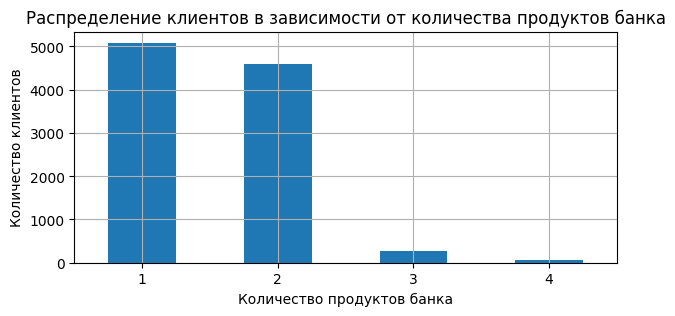

In [33]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['products'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от количества продуктов банка'
)

# Настраиваем оформление графика
plt.xlabel('Количество продуктов банка')
plt.ylabel('Количество клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из категорий по количеству продуктов две значительно преобладают — теперь это хорошо видно.

---

### 3.2. Непрерывные числовые данные

Теперь посмотрим на данные кредитного рейтинга клиента `score` и его баланса на счёте `balance`. Значения в них относятся к непрерывным вещественным данным.

Начнём с баланса — при знакомстве с подобными данными вначале стоит оценить статические показатели. Для этого используем метод `describe()`:

In [34]:
# Изучаем статистические показатели столбца balance
print('Статистические показатели столбца balance:')
df['balance'].describe()

Статистические показатели столбца balance:


count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
Name: balance, dtype: float64

Можно предположить, что данные баланса имеют распределение, близкое к нормальному. Об этом говорит близость среднего и медианного значений. Однако значение стандартного отклонения довольно высокое — 30095.06, и при среднем 119827.49 это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.

Дополнительно проверим это и построим гистограмму распределения значений и диаграмму размаха для столбца с балансом.

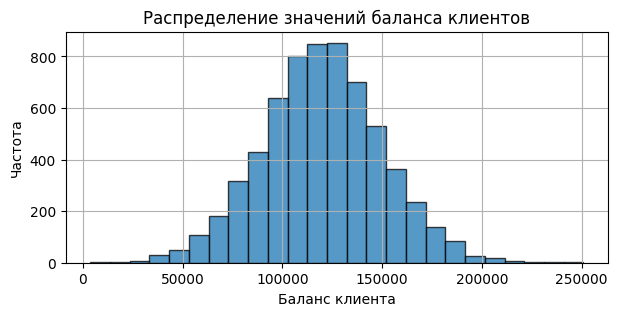

In [35]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['balance'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений баланса клиентов')
plt.xlabel('Баланс клиента')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

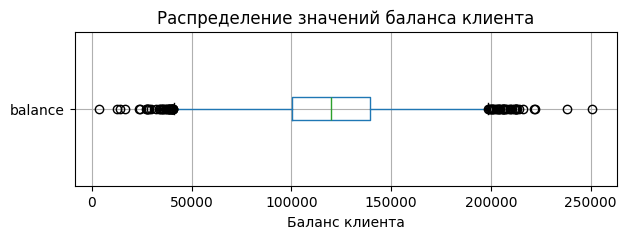

In [36]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='balance', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений баланса клиента')
plt.xlabel('Баланс клиента')

# Выводим график
plt.show()

Распределение данных действительно выглядит нормальным, однако характеризуется широким разбросом и «хвостами» как в левой, так и в правой части гистограммы. Такие низкие и высокие значения можно отнести к выбросам. Однако сами значения, как минимальные, так и максимальные, не выглядят ошибкой, и такой баланс у клиента вполне допустим. Поэтому при анализе данных их оставим.

Теперь изучим распределение значений в столбце `score`:

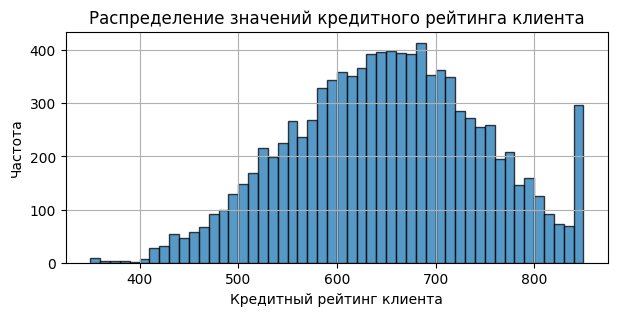

In [37]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['score'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений кредитного рейтинга клиента')
plt.xlabel('Кредитный рейтинг клиента')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

На гистограмме видно, что распределение значений в столбце `score` приближается к нормальному, но резко увеличивается количество высоких значений, близких к 850. Такой пик может означать, что 850 — это значение-индикатор, которое отражает пропуски. Например, у таких клиентов может не быть кредитного рейтинга, так как ранее они не оформляли кредиты. Может быть и другое объяснение. Допустим, кредитный рейтинг клиента составляет больше 850. Если значение 850 является максимальным, то всем клиентам с рейтингом выше может присваиваться значение 850.

Проверим эту особенность данных отдельно и изучим распределение данных для значений рейтинга от 840 до 850:

In [38]:
# Проверяем распределение данных по значениям столбца score 840 и выше
print('Распределение данных по значениям столбца score 840 и выше:')
df.loc[df['score'] >= 840]['score'].value_counts()

Распределение данных по значениям столбца score 840 и выше:


score
850    233
841     12
849      8
842      7
844      7
845      6
847      6
846      5
840      5
848      5
843      2
Name: count, dtype: int64

Действительно, данных с рейтингом 850 значительно больше, чем с рейтингом от 840 до 849. Это может подтвердить одну из предложенных гипотез.

---

### 3.3. Бинарные признаки и категориальные данные

Изучение бинарных признаков и категориальных данных похоже на изучение дискретных числовых данных с небольшим количеством значений. Для бинарных признаков важно оценить, как распределяются клиенты между признаками, а для категориальных данных — убедиться, что в них нет ошибок, а также проверить распределение значений по категориям.

При исследовании таких данных можно использовать метод `value_counts()` с аргументом `normalize=True`, чтобы сравнить доли значений. Изучим значения в столбцах с бинарными признаками, применив метод `value_counts()` для каждого столбца в цикле:

In [39]:
# Проверяем распределение данных по значениям в столбце
for column in ['credit_card','loyalty','churn']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts(normalize=True))
    print()

Распределение данных по значениям столбца credit_card:
credit_card
1    0.7055
0    0.2945
Name: proportion, dtype: float64

Распределение данных по значениям столбца loyalty:
loyalty
1    0.5151
0    0.4849
Name: proportion, dtype: float64

Распределение данных по значениям столбца churn:
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64



Доля нелояльных клиентов, которые покинули банк, из столбца `churn` составляет около 20%, а доля клиентов без кредитных карт из столбца `credit_card` — около 30%. Распределение данных по уникальным значениям столбца `loyalty` примерно равно — 51% к 49%. Так соотносятся клиенты, которые участвуют в программах лояльности банка, с теми, кто предпочитает в них не участвовать.

Результаты `value_counts()` можно также визуализировать с помощью столбчатой диаграммы. Посмотрим на распределение клиентов по значениям в столбцах с полом клиента и городом:

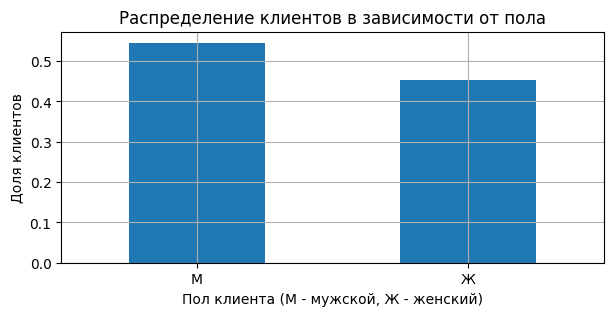

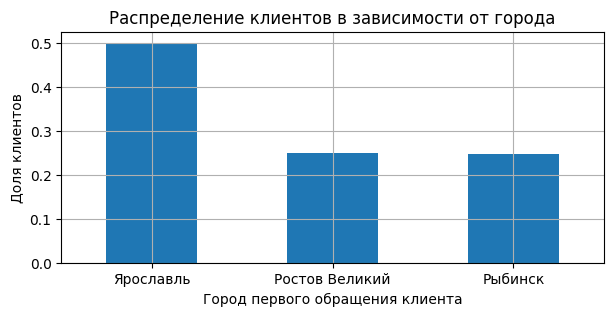

In [40]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['gender'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика — столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от пола'
)

# Настраиваем оформление графика
plt.xlabel('Пол клиента (М - мужской, Ж - женский)')
plt.ylabel('Доля клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['city'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от города'
)

# Настраиваем оформление графика
plt.xlabel('Город первого обращения клиента')
plt.ylabel('Доля клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Судя по диаграммам, примерно 55% клиентов — женщины. Половина клиентов представляют Ярославль, а остальная половина — Ростов Великий и Рыбинск примерно поровну.

---

Используя код этого блока, самостоятельно изучите данные в остальных столбцах.

---

In [65]:
# Задаём функцию для анализа данных
def plot_bar_plot(df, groupby, value, aggfunc, title, ylabel, xlabel, figsize=(7, 3)):
    '''
    Функция для анализа распределения метрики по признакам:
    df - датафрейм с данными для анализа;
    groupby - str, название столбца для группировки данных;
    value - str, название столбца, значение которого будет агрегироваться;
    aggfunc - str, функция агрегации, которая используется для расчёта;
    title - str, заголовок графика;
    ylabel - str, подпись по оси Y;
    xlabel - str, подпись по оси X.
    '''
    grouped = df.groupby(groupby).agg({value:aggfunc})
    ax = grouped.plot(kind='bar',                   
                   title=title,
                   legend=True,
                   ylabel=ylabel,
                   xlabel=xlabel,
                   rot=90,
                   figsize=figsize)

    # Форматируем ось Y в процентах
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

    # Рассчитываем общее значение value по всем данным
    mean_churn_share = df.agg({value:aggfunc}).iloc[0]

    # Наносим на график линию с значением value по всем данным
    plt.axhline(mean_churn_share, color='red',
                linestyle='--', linewidth=1,
                label=f'Значение по всем данным {round(mean_churn_share*100, 2)}%')

    plt.grid()
    plt.legend()
    plt.show()

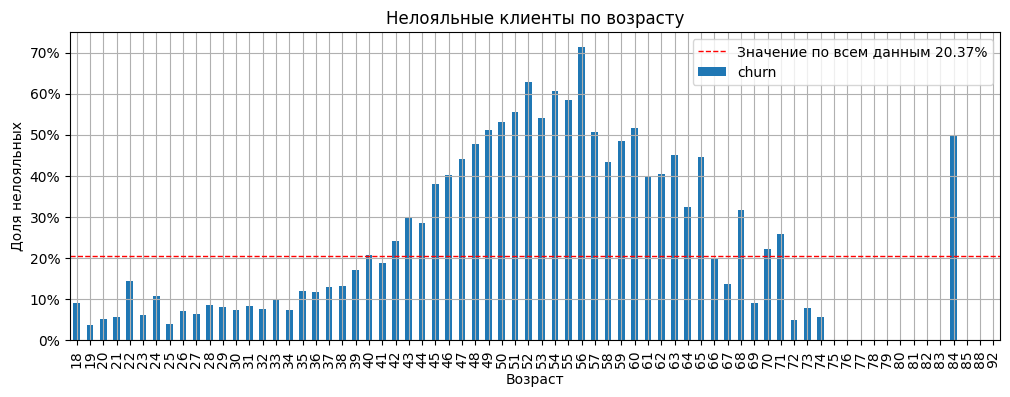

In [66]:
plot_bar_plot(df, 'age', 'churn', 'mean', 'Нелояльные клиенты по возрасту', 'Доля нелояльных', 'Возраст', (12, 4))

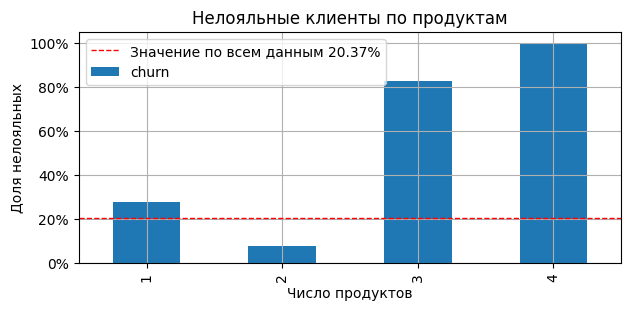

In [68]:
plot_bar_plot(df, 'products', 'churn', 'mean', 'Нелояльные клиенты по продуктам', 'Доля нелояльных', 'Число продуктов')